## Welcome to PyLMD!

This notebook demonstrates how you can use the Localized Marker Detector algorithm to identify genes whose expression is restricted to particular groups of similar cells.

First import the necessary libraries, including pylmd. To install pylmd, please clone the repository from https://github.com/jassonmakkar/pylmd and run "pip install -e ." in the download directory.

In [1]:
import sys
import os
from pylmd import lmd, utils, cluster, plot
import scanpy as sc
import numpy as np
import pandas as pd
import pooch
import matplotlib.pyplot as plt
import warnings

Define the device you will be using to perform the analysis. **IMPORTANT** Please use 'gpu' here if you have an NVIDIA GPU and have installed CUDA, CuPy, and RAPIDS-singlecell.

In [2]:
device = 'gpu'
max_time = 2**20

In [3]:
# Retreive the necessary packages based on selected device type.
device_libs = lmd.get_xp(device)

In [4]:
xsc = device_libs['xsc']

In [5]:
# Download sample dataset.
EXAMPLE_DATA = pooch.create(
    path=pooch.os_cache("scverse_tutorials"),
    base_url="doi:10.6084/m9.figshare.22716739.v1/",
)
EXAMPLE_DATA.load_registry_from_doi()

path = EXAMPLE_DATA.fetch('s1d1_filtered_feature_bc_matrix.h5')

In [6]:
# Read in data from path.
adata = sc.read_10x_h5(path)

/opt/conda/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/conda/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [7]:
adata.var_names_make_unique()

In [8]:
# Move data to the GPU (if selected)
if device == 'gpu':
    xsc.get.anndata_to_GPU(adata)

In [9]:
# Filter cells and genes (default: filter cells with < 100 genes = 100; filter genes expressed in < 3 cells)
xsc.pp.filter_cells(adata, min_genes=100)
xsc.pp.filter_genes(adata, min_cells=3)

filtered out 72 cells that have less than 100 genes expressed
filtered out 14926 genes that are detected in less than 3 cells


In [10]:
# Copy adata object to preserve raw counts.
raw_adata = adata.copy()

In [11]:
# Extract raw gene x cell expression matrix.
dat = pd.DataFrame(
    raw_adata.X.get().T.toarray() if not isinstance(raw_adata.X, np.ndarray) else raw_adata.X.T,
    index=adata.var_names,       # genes
    columns=adata.obs_names      # cells
)

In [12]:
dat

,AAACCCAAGGATGGCT-1,AAACCCAAGGCCTAGA-1,AAACCCAAGTGAGTGC-1,AAACCCACAAGAGGCT-1,AAACCCACATCGTGGC-1,AAACCCACATTCTCTA-1,AAACCCAGTCCGCAGT-1,AAACCCAGTGCATACT-1,AAACCCAGTTGACGGA-1,AAACCCATCGATACTG-1,...,TTTGTTGAGCTTACGT-1,TTTGTTGAGGGATCGT-1,TTTGTTGAGGTTACCT-1,TTTGTTGAGTAGTCCT-1,TTTGTTGAGTCTAGAA-1,TTTGTTGCAAATCAGA-1,TTTGTTGCACGCCACA-1,TTTGTTGCATAGGAGC-1,TTTGTTGCATTCGATG-1,TTTGTTGGTCACTCAA-1
AL627309.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AL627309.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AL669831.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
LINC01409,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
FAM87B,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AC240274.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AC004556.3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AC233755.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AC233755.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
# Perform normalization, feature selection, scaling, and dimensional reduction.
xsc.pp.normalize_total(adata)
xsc.pp.log1p(adata)
xsc.pp.highly_variable_genes(adata, n_top_genes=2000)
xsc.pp.scale(adata,max_value=10)
xsc.tl.pca(adata)
xsc.get.anndata_to_CPU(adata)
xsc.pp.neighbors(adata)
xsc.tl.umap(adata)

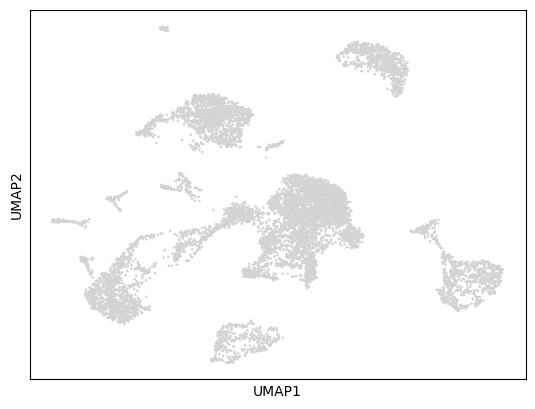

In [14]:
# Plot of UMAP coordinates.
sc.pl.umap(adata)

In [15]:
# Selects genes that have higher than median expression in at least 10 cells and removes genes expressed in greater than 30% of cells (moderately expressed genes)
cell_medians = np.median(dat, axis=0)
mask = dat > cell_medians

gene_detected_count = mask.sum(axis=1)

selected_genes = (gene_detected_count >= 10) & (gene_detected_count <= dat.shape[1] * 0.3)

In [16]:
# Filters objects for selected genes.
adata = adata[:, selected_genes].copy()
raw_adata = raw_adata[:, selected_genes].copy()
dat = dat[selected_genes]

In [17]:
adata

AnnData object with n_obs × n_vars = 8713 × 16952
    obs: 'n_counts', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [18]:
# Extracts top 20 PCs
feature_space = adata.obsm['X_pca'][:, :20]

In [19]:
# Builds an affinity network for connecting cells based on similarity.
W = lmd.build_network(feature_space, n_neighbors=5)

In [20]:
W

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 66864 stored elements and shape (8713, 8713)>

(<Figure size 800x800 with 1 Axes>, <Axes: >)

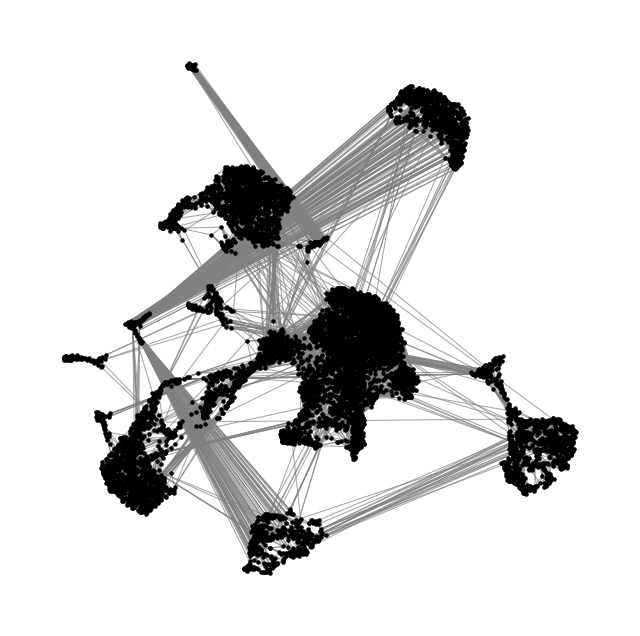

In [21]:
plot.visualize_network(W, adata)

In [22]:
rho = lmd.rowwise_normalize(dat, W)

In [23]:
rho

,AAACCCAAGGATGGCT-1,AAACCCAAGGCCTAGA-1,AAACCCAAGTGAGTGC-1,AAACCCACAAGAGGCT-1,AAACCCACATCGTGGC-1,AAACCCACATTCTCTA-1,AAACCCAGTCCGCAGT-1,AAACCCAGTGCATACT-1,AAACCCAGTTGACGGA-1,AAACCCATCGATACTG-1,...,TTTGTTGAGCTTACGT-1,TTTGTTGAGGGATCGT-1,TTTGTTGAGGTTACCT-1,TTTGTTGAGTAGTCCT-1,TTTGTTGAGTCTAGAA-1,TTTGTTGCAAATCAGA-1,TTTGTTGCACGCCACA-1,TTTGTTGCATAGGAGC-1,TTTGTTGCATTCGATG-1,TTTGTTGGTCACTCAA-1
AL627309.1,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AL627309.5,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
LINC01409,0.0,0.000000,0.0,0.002079,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
LINC01128,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000841,0.0,0.0,0.0
LINC00115,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AL592183.1,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.001642,...,0.0,0.001642,0.001642,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AC240274.1,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AC004556.3,0.0,0.000922,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000922,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AC233755.1,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


In [24]:
# Constructs the diffusion operators to describe diffusion across this network agnostic of individual gene expression.
P_ls = lmd.construct_diffusion_operators(W, device_libs, max_time)

Creating diffusion operators...
Step 1: max deviation from convergence = 8713.0
Step 2: max deviation from convergence = 25809436.0
Step 3: max deviation from convergence = 10944500.0
Step 4: max deviation from convergence = 7396620.0
Step 5: max deviation from convergence = 5266180.5
Step 6: max deviation from convergence = 3452121.0
Step 7: max deviation from convergence = 1521881.625
Step 8: max deviation from convergence = 898192.4375
Step 9: max deviation from convergence = 605454.1875
Step 10: max deviation from convergence = 281066.28125
Step 11: max deviation from convergence = 63136.625
Step 12: max deviation from convergence = 9905.556640625
Step 13: max deviation from convergence = 1066.939453125
Converged at step 13 (time = 4096)
Max diffusion time: 4096
Total operators created: 13


In [25]:
P_ls

{0: <cupyx.scipy.sparse._csr.csr_matrix at 0x7f28caefe510>,
 2: <cupyx.scipy.sparse._csc.csc_matrix at 0x7f275f8275f0>,
 4: <cupyx.scipy.sparse._csc.csc_matrix at 0x7f2731703860>,
 8: <cupyx.scipy.sparse._csc.csc_matrix at 0x7f275f827bf0>,
 16: <cupyx.scipy.sparse._csc.csc_matrix at 0x7f275f826ed0>,
 32: <cupyx.scipy.sparse._csc.csc_matrix at 0x7f27697e26f0>,
 64: <cupyx.scipy.sparse._csc.csc_matrix at 0x7f2731703710>,
 128: <cupyx.scipy.sparse._csc.csc_matrix at 0x7f27519daa50>,
 256: <cupyx.scipy.sparse._csc.csc_matrix at 0x7f275f8825a0>,
 512: <cupyx.scipy.sparse._csc.csc_matrix at 0x7f275f883560>,
 1024: <cupyx.scipy.sparse._csc.csc_matrix at 0x7f27519da5d0>,
 2048: <cupyx.scipy.sparse._csc.csc_matrix at 0x7f275f882690>,
 4096: <cupyx.scipy.sparse._csc.csc_matrix at 0x7f27519da270>}

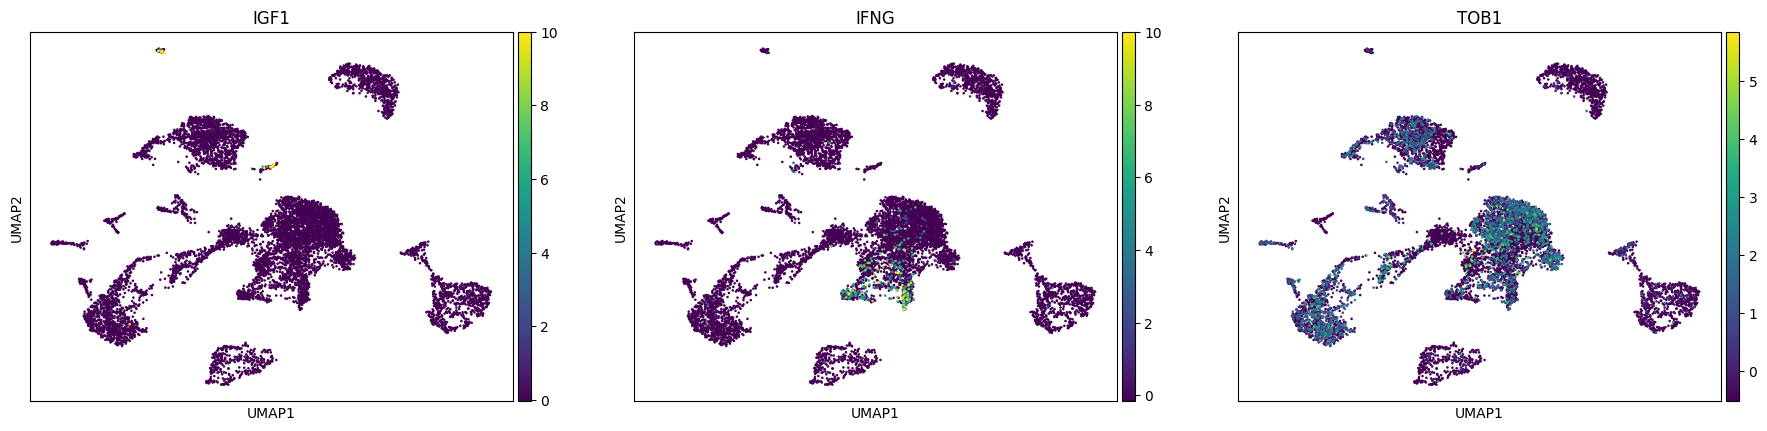

In [26]:
sc.pl.umap(adata, color = ['IGF1','IFNG','TOB1'])

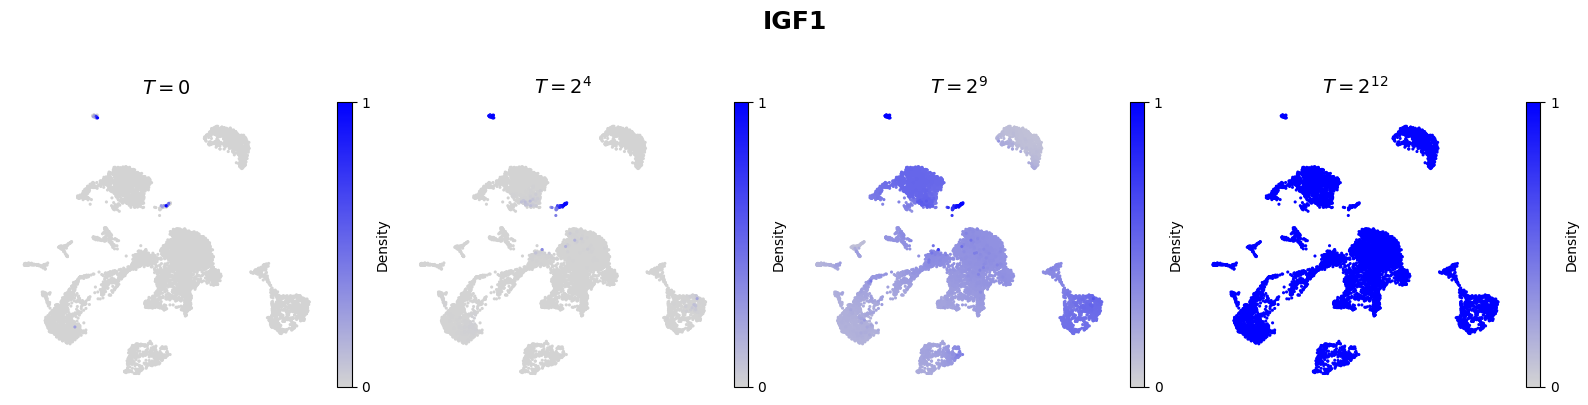

In [27]:
fig, axes = plot.visualize_diffusion(adata, rho, P_ls, 'IGF1')

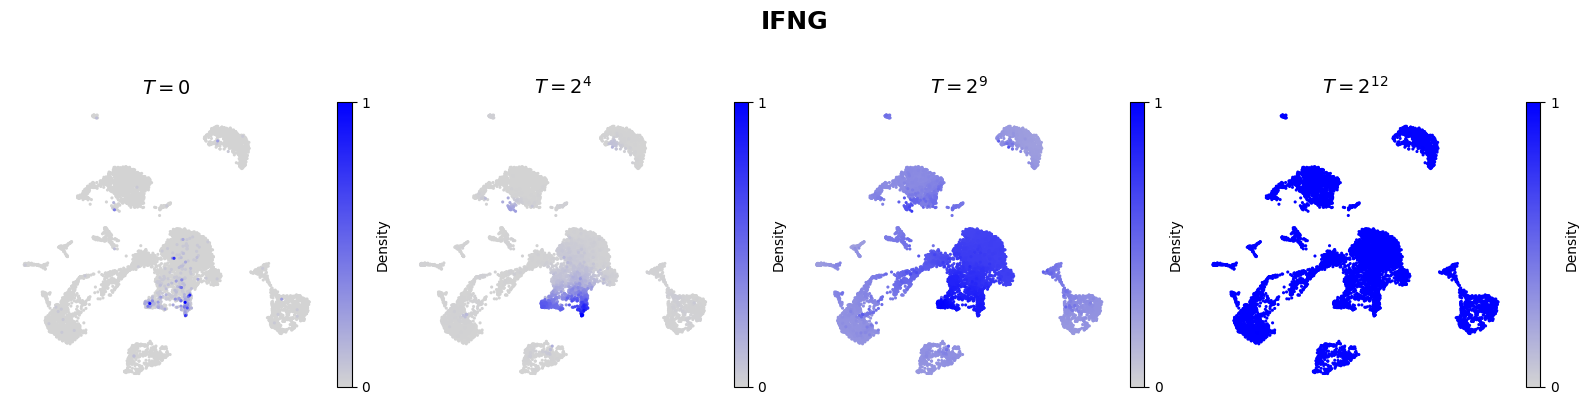

In [28]:
fig, axes = plot.visualize_diffusion(adata, rho, P_ls, 'IFNG')

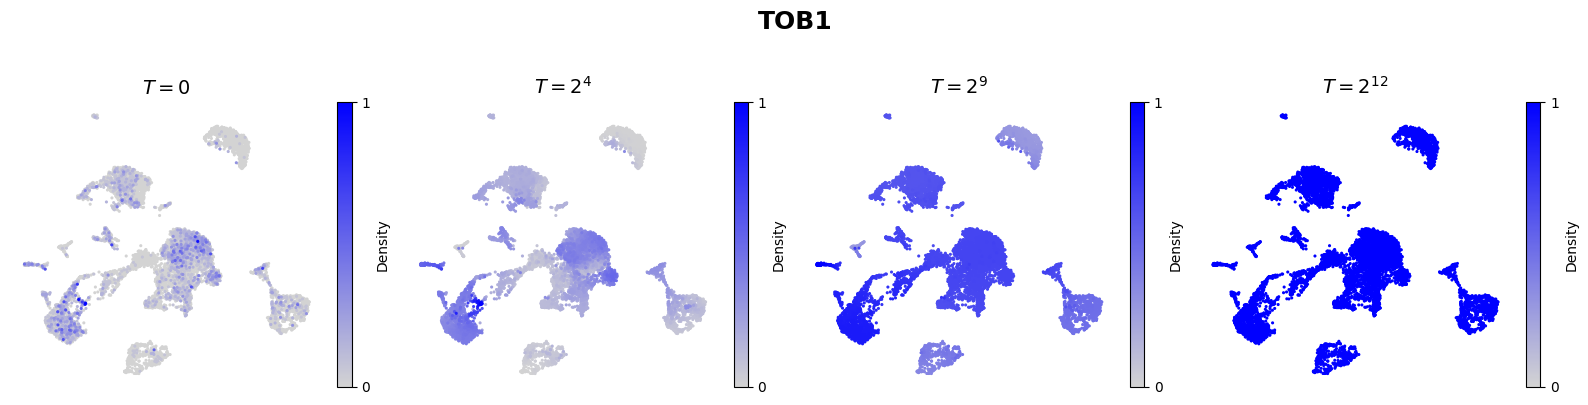

In [29]:
fig, axes = plot.visualize_diffusion(adata, rho, P_ls, 'TOB1')

In [30]:
# Scores each genes diffusivity over time based on the calculated diffusion operators.
score_df = lmd.calculate_score_profile(W, rho, P_ls, device_libs)

Completed scoring for time 0
Completed scoring for time 2
Completed scoring for time 4
Completed scoring for time 8
Completed scoring for time 16
Completed scoring for time 32
Completed scoring for time 64
Completed scoring for time 128
Completed scoring for time 256
Completed scoring for time 512
Completed scoring for time 1024
Completed scoring for time 2048
Completed scoring for time 4096


In [31]:
score_df

,0_0,0_2,0_4,0_8,0_16,0_32,0_64,0_128,0_256,0_512,0_1024,0_2048,0_4096,0
AL627309.1,0.0,1.828948,2.791358,3.857164,4.659682,5.145946,5.427519,5.564531,5.657625,5.733522,5.800491,5.840962,5.852551,5.853700
AL627309.5,0.0,1.674847,2.382705,2.985025,3.338952,3.511841,3.614352,3.699465,3.801140,3.971266,4.238175,4.469574,4.524757,4.526448
LINC01409,0.0,1.483764,2.022780,2.418192,2.606418,2.703040,2.773392,2.835397,2.898672,2.955365,2.997597,3.023739,3.031213,3.031843
LINC01128,0.0,1.006263,1.309046,1.512206,1.603367,1.648974,1.685369,1.725723,1.786220,1.900177,2.095821,2.291564,2.354734,2.359099
LINC00115,0.0,1.736224,2.529843,3.279760,3.723930,3.915089,4.005073,4.056680,4.094358,4.129021,4.163755,4.186215,4.192171,4.192639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AL592183.1,0.0,1.335490,1.789288,2.107244,2.260722,2.358647,2.458236,2.557633,2.640937,2.699906,2.748736,2.778136,2.786280,2.787117
AC240274.1,0.0,1.744065,2.601721,3.462709,4.008636,4.263976,4.421663,4.530312,4.613212,4.683085,4.747336,4.794527,4.809215,4.810540
AC004556.3,0.0,1.030028,1.336188,1.551586,1.681897,1.787848,1.896377,2.004318,2.112487,2.229808,2.355954,2.439807,2.457887,2.458467
AC233755.1,0.0,1.661047,2.261656,2.836627,3.320771,3.733104,4.016111,4.280920,4.710338,5.336922,5.761220,5.958116,6.010099,6.014232


In [32]:
# Normalizes each genes score based on its maximum obtainable score (makes genes comparable).
norm_scores, lmd_scores = lmd.obtain_lmds(score_df)

In [33]:
norm_scores

,0_0,0_2,0_4,0_8,0_16,0_32,0_64,0_128,0_256,0_512,0_1024,0_2048,0_4096
AL627309.1,0.0,0.312443,0.476854,0.658927,0.796023,0.879093,0.927195,0.950601,0.966504,0.979470,0.990910,0.997824,0.999804
AL627309.5,0.0,0.370014,0.526396,0.659463,0.737654,0.775849,0.798496,0.817300,0.839762,0.877347,0.936314,0.987435,0.999626
LINC01409,0.0,0.489393,0.667178,0.797598,0.859681,0.891550,0.914754,0.935206,0.956076,0.974775,0.988705,0.997327,0.999792
LINC01128,0.0,0.426546,0.554892,0.641010,0.679652,0.698985,0.714412,0.731518,0.757162,0.805467,0.888399,0.971373,0.998150
LINC00115,0.0,0.414113,0.603401,0.782266,0.888207,0.933801,0.955263,0.967572,0.976559,0.984826,0.993111,0.998468,0.999888
...,...,...,...,...,...,...,...,...,...,...,...,...,...
AL592183.1,0.0,0.479165,0.641985,0.756066,0.811133,0.846268,0.881999,0.917662,0.947551,0.968709,0.986229,0.996778,0.999699
AC240274.1,0.0,0.362551,0.540838,0.719817,0.833303,0.886382,0.919161,0.941747,0.958980,0.973505,0.986861,0.996671,0.999724
AC004556.3,0.0,0.418972,0.543504,0.631119,0.684125,0.727221,0.771366,0.815272,0.859270,0.906991,0.958302,0.992410,0.999764
AC233755.1,0.0,0.276186,0.376051,0.471652,0.552152,0.620712,0.667768,0.711798,0.783199,0.887382,0.957931,0.990669,0.999313


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Gene Scores Over Time'}, xlabel='Time', ylabel='Normalized Diffusion KL Score'>)

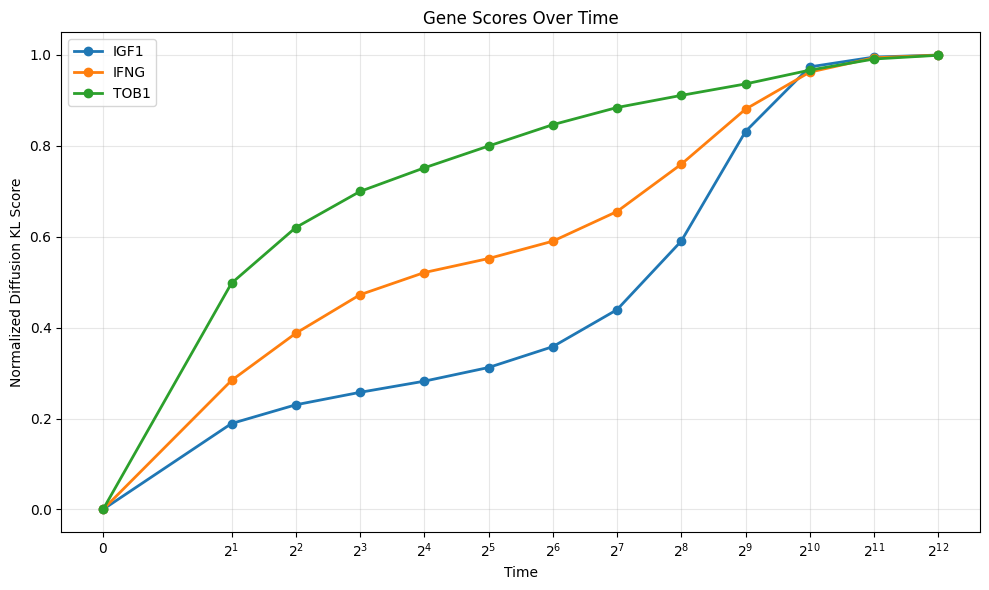

In [34]:
plot.visualize_score_pattern(norm_scores, genes = ['IGF1','IFNG','TOB1'])

In [35]:
sort_score = lmd_scores.sort_values()

In [36]:
# Top 10 localized genes
sort_score[:10]

SNCA      3.733672
LILRA4    3.752784
ALAS2     3.872074
SLC4A1    3.885415
HEMGN     4.077516
BPGM      4.091650
GYPA      4.161524
IFIT1B    4.195690
RHAG      4.239954
GYPB      4.277653
Name: LMDS, dtype: float32

In [37]:
# Bottom 10 localized genes
sort_score[int(len(sort_score)-10):]

GPM6A      10.823456
ZNF805     10.830006
ANKZF1     10.831145
CTC1       10.838760
ATXN1L     10.839416
PLCL2      10.873769
CRTC2      10.876394
ZNF335     10.877094
KHNYN      10.927414
ST3GAL1    10.961809
Name: LMDS, dtype: float32

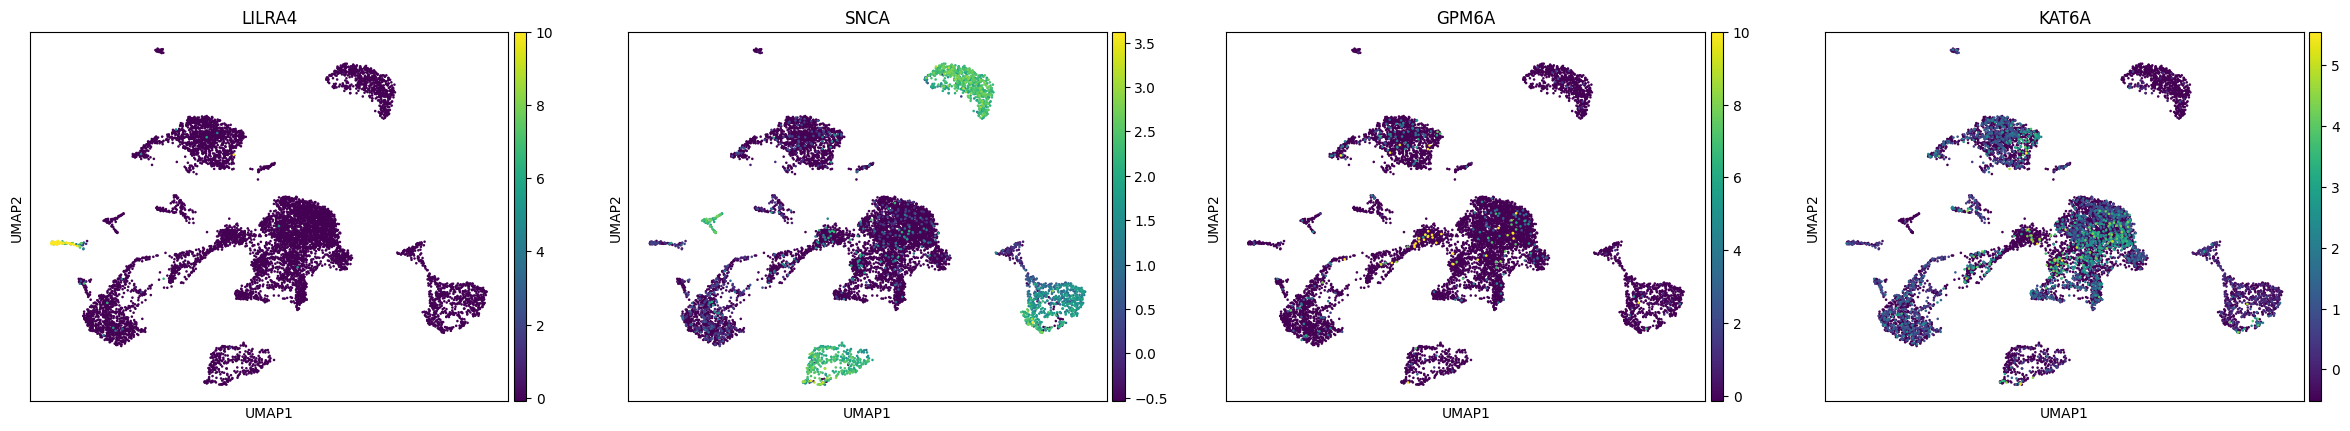

In [38]:
sc.pl.umap(adata, color = ['LILRA4', 'SNCA', 'GPM6A', 'KAT6A'])

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Gene Scores Over Time'}, xlabel='Time', ylabel='Normalized Diffusion KL Score'>)

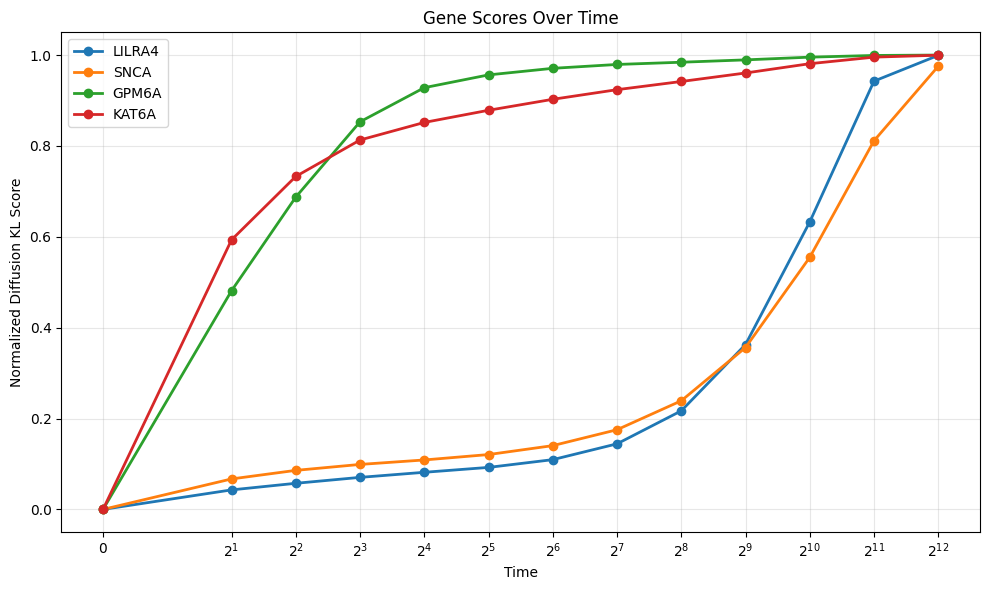

In [39]:
plot.visualize_score_pattern(norm_scores, genes = ['LILRA4', 'SNCA', 'GPM6A', 'KAT6A'])

In [40]:
# Identifies cutoff for localized genes
knee = lmd.find_knee(lmd_scores)

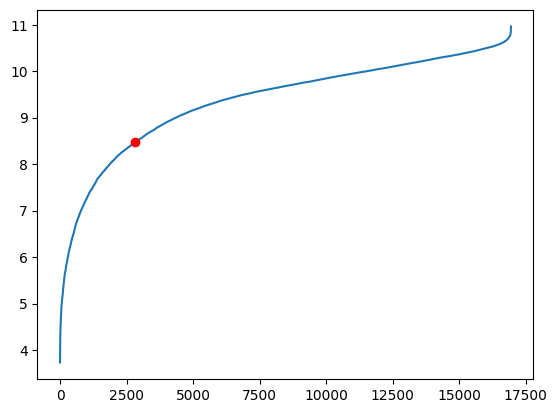

In [41]:
plt.plot(sorted(lmd_scores))
plt.plot(knee, sorted(lmd_scores)[knee], 'ro')

plt.show()

In [42]:
LMDs = list(lmd_scores.sort_values()[:knee].index)

In [43]:
LMDs[:10]

['SNCA',
 'LILRA4',
 'ALAS2',
 'SLC4A1',
 'HEMGN',
 'BPGM',
 'GYPA',
 'IFIT1B',
 'RHAG',
 'GYPB']